# Solute Transport Toy: mPCN P vs rho sweep

Run mPCN across P and rho for the advection-diffusion toy, with MESS baselines and ellipse diagnostics in the proposal plane.

In [ ]:
import os
import sys
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'pyproject.toml').exists():
    repo_root = repo_root.parent
src_path = repo_root / 'src'
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from multiproposal.problems.advection_diffusion import (
    make_omegas_power,
    make_Astar_nn,
    make_Astar_from_atrue,
    params_from_skew,
    prior_diag_from_powerlaw,
    solve_theta,
 )
from multiproposal.problems.advection_diffusion import AdvectionDiffusionToy
from multiproposal.algorithms.mpcn import mpcn_chain
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import estimate_effective_sample_size
from multiproposal.plotting.diagnostics import make_hist_grid_comps

In [2]:
# Data configuration
seed_data = 0
seed_mcmc = 0

d = 10
kappa = 0.02
sigma = 0.5
alpha = 3.0
gamma = 2.0
tau2 = 2.0
a_mode = 'nearest_neighbor'
use_prior_A = True
shared_draws_seed = seed_data

obs_highest_freq = 6
obs_bandwidth = 3
obs_config = 'central_modes'

print('d:', d)
print('kappa:', kappa)
print('sigma:', sigma)
print('obs_config:', obs_config)

d: 10
kappa: 0.02
sigma: 0.5
obs_config: central_modes


In [3]:
# Sweep configuration
n_iters = 10000
P_list = [10, 20, 30, 40]
M_list = P_list
rho_list = [round(val, 1) for val in np.arange(0.1, 1.0, 0.1)]
burn_in = 500
max_lag = 500
plot_iter = 0
n_diag_samples = 100
seed_base = 202

print('P_list:', P_list)
print('rho_list:', rho_list)
print('n_iters:', n_iters)
print('n_diag_samples:', n_diag_samples)

P_list: [10, 20, 30, 40]
rho_list: [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9)]
n_iters: 10000
n_diag_samples: 100


In [4]:
def compute_msjd_per_param(chain):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    jumps = np.diff(chain, axis=0)
    msjd = np.mean(jumps * jumps, axis=0)
    return msjd


def compute_ess_per_param(chain, max_lag):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    variances = np.var(chain, axis=0)
    if np.all(variances == 0):
        return np.zeros(chain.shape[1])
    ess_vals = estimate_effective_sample_size(chain, max_lag=max_lag)
    ess_vals = np.asarray(ess_vals, dtype=float)
    ess_vals[variances == 0] = 0.0
    return ess_vals


def summarize_chain_metrics(chain, runtime_sec, burn_in, max_lag):
    post = chain[burn_in:]
    ess_vals = compute_ess_per_param(post, max_lag=max_lag)
    msjd_vals = compute_msjd_per_param(post)
    ess_mean = float(np.nanmean(ess_vals)) if ess_vals.size else 0.0
    msjd_mean = float(np.nanmean(msjd_vals)) if msjd_vals.size else 0.0
    runtime_min = runtime_sec / 60.0
    ess_per_min = ess_mean / runtime_min if runtime_min > 0 else np.nan
    return {
        'runtime_sec': runtime_sec,
        'runtime_min': runtime_min,
        'ess_mean': ess_mean,
        'msjd_mean': msjd_mean,
        'ess_per_min': ess_per_min,
    }


def run_mpcn_chain(problem, x0, n_iters, rho, n_props, seed, diag_indices=None):
    rng = np.random.default_rng(seed)
    t0 = time.perf_counter()
    return_diag = diag_indices is not None
    if return_diag:
        chain, accepted_index, diagnostics = mpcn_chain(
            x0,
            problem,
            rng,
            n_iters,
            rho=rho,
            n_props=n_props,
            return_indices=True,
            return_diagnostics=True,
            diag_indices=diag_indices,
        )
    else:
        chain, accepted_index = mpcn_chain(
            x0,
            problem,
            rng,
            n_iters,
            rho=rho,
            n_props=n_props,
            return_indices=True,
        )
        diagnostics = None
    runtime_sec = time.perf_counter() - t0
    accept_rate = float(np.mean(accepted_index != 0))
    return chain, runtime_sec, accept_rate, diagnostics


def run_mess_chain(problem, x0, n_iters, M, seed, use_lp=False, distance_metric='angular', lam=0.0):
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters + 1, problem.dim), dtype=float)
    chain[0] = x0
    x = x0.copy()
    t0 = time.perf_counter()
    for t in range(n_iters):
        x, _, _ = mess_step(
            x,
            problem,
            rng,
            M=M,
            use_lp=use_lp,
            distance_metric=distance_metric,
            lam=lam,
        )
        chain[t + 1] = x
    runtime_sec = time.perf_counter() - t0
    return chain, runtime_sec

In [5]:
# Shared-draws helpers
datasets_by_dim = {}

def get_obs_indices(dim_value, highest_freq, bandwidth):
    highest_freq = min(highest_freq, dim_value)
    bandwidth = min(bandwidth, dim_value)
    start = max(0, highest_freq - bandwidth + 1)
    return np.arange(start, highest_freq + 1, dtype=int)


def get_param_indices_for_dim(dim, shared_draws):
    cache = shared_draws.setdefault('param_indices_cache', {})
    if dim not in cache:
        iju = shared_draws['param_iju']
        mask = (iju[0] < dim) & (iju[1] < dim)
        cache[dim] = np.nonzero(mask)[0]
    return cache[dim]


def build_shared_draws(
    d_max,
    kappa,
    sigma,
    alpha,
    gamma,
    tau2,
    offset,
    a_mode,
    seed,
):
    rng = np.random.default_rng(seed)
    m_max = d_max * (d_max - 1) // 2
    prior_diag_max = prior_diag_from_powerlaw(
        d_max, alpha=alpha, gamma=gamma, tau2=tau2, offset=offset
    )
    if prior_diag_max.shape != (m_max,):
        raise ValueError(f'prior_diag_max must have shape ({m_max},), got {prior_diag_max.shape}')
    if a_mode == 'nearest_neighbor':
        omegas = make_omegas_power(d_max, beta=alpha, c=2.0 ** (-gamma), offset=offset)
        A_true_max = make_Astar_nn(d_max, omegas)
        a_true_max = params_from_skew(A_true_max)
    elif a_mode == 'prior':
        z_prior = rng.standard_normal(m_max)
        a_true_max = z_prior * np.sqrt(prior_diag_max)
        A_true_max = make_Astar_from_atrue(d_max, a_true_max)
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    g_max = np.zeros(d_max, dtype=float)
    g_max[0] = 1.0
    theta_true_max = solve_theta(d_max, a_true_max, g_max, kappa)
    noise_max = rng.standard_normal(d_max)
    z_init = rng.standard_normal(m_max)
    a_init_max = z_init * np.sqrt(prior_diag_max)
    return {
        'd_max': d_max,
        'm_max': m_max,
        'kappa': kappa,
        'sigma': sigma,
        'alpha': alpha,
        'gamma': gamma,
        'tau2': tau2,
        'offset': offset,
        'a_mode': a_mode,
        'param_iju': np.triu_indices(d_max, k=1),
        'param_indices_cache': {},
        'prior_diag': prior_diag_max,
        'a_true': a_true_max,
        'A_true': A_true_max,
        'g': g_max,
        'theta_true': theta_true_max,
        'noise': noise_max,
        'a_init': a_init_max,
    }


def generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws):
    a_mode_local = shared_draws['a_mode']
    param_idx = get_param_indices_for_dim(dim, shared_draws)
    prior_diag = shared_draws['prior_diag'][param_idx]
    g = shared_draws['g'][:dim]
    if a_mode_local == 'nearest_neighbor':
        omegas = make_omegas_power(
            dim,
            beta=shared_draws['alpha'],
            c=2.0 ** (-shared_draws['gamma']),
            offset=shared_draws['offset'],
        )
        A_true = make_Astar_nn(dim, omegas)
        a_true = params_from_skew(A_true)
        theta_true = solve_theta(dim, a_true, g, shared_draws['kappa'])
    elif a_mode_local == 'prior':
        a_true = shared_draws['a_true'][param_idx]
        A_true = make_Astar_from_atrue(dim, a_true)
        theta_true = shared_draws['theta_true'][:dim]
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    noise = shared_draws['noise'][:dim]
    y = theta_true[obs_indices] + shared_draws['sigma'] * noise[obs_indices]
    a_init = shared_draws['a_init'][param_idx]
    return {
        'dim': dim,
        'kappa': shared_draws['kappa'],
        'alpha': shared_draws['alpha'],
        'gamma': shared_draws['gamma'],
        'tau2': shared_draws['tau2'],
        'sigma': shared_draws['sigma'],
        'obs_indices': obs_indices,
        'prior_diag': prior_diag,
        'a_true': a_true,
        'A_true': A_true,
        'g': g,
        'theta_true': theta_true,
        'y': y,
        'a_init': a_init,
    }


def build_problem_for_dim(dim, shared_draws):
    obs_indices = get_obs_indices(dim, obs_highest_freq, obs_bandwidth)
    data = generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws)
    problem = AdvectionDiffusionToy(
        dim=dim,
        kappa=kappa,
        sigma=sigma,
        y=data['y'],
        obs_indices=obs_indices,
        g=data['g'],
        prior_diag=data['prior_diag'],
    )
    return problem, data['a_init'], data

In [6]:
shared_draws = build_shared_draws(
    d_max=d,
    kappa=kappa,
    sigma=sigma,
    alpha=alpha,
    gamma=gamma,
    tau2=tau2,
    offset=1.0,
    a_mode='prior' if use_prior_A else a_mode,
    seed=shared_draws_seed,
)
problem, a_init, data = build_problem_for_dim(d, shared_draws)
x0 = a_init.copy()

print('Shared draws ready with d:', d)
print('Initial x0 norm:', np.linalg.norm(x0))

Shared draws ready with d: 10
Initial x0 norm: 0.12192810032786688


In [7]:
# Run sweep
results = {'mpcn': {}, 'mess_uniform': {}, 'mess_euclid_sq': {}}

for P in P_list:
    results['mpcn'][P] = {}
    for rho in rho_list:
        seed = seed_base + int(P * 1000 + round(rho * 100))
        rng_diag = np.random.default_rng(seed)
        diag_pool = np.arange(burn_in, n_iters)
        replace = n_diag_samples > diag_pool.size
        diag_indices = rng_diag.choice(diag_pool, size=n_diag_samples, replace=replace)

        chain, runtime_sec, accept_rate, diagnostics = run_mpcn_chain(
            problem, x0, n_iters, rho=rho, n_props=P, seed=seed, diag_indices=diag_indices
        )
        metrics = summarize_chain_metrics(chain, runtime_sec, burn_in=burn_in, max_lag=max_lag)

        mean_dist_samples = []
        mean_sq_dist_samples = []
        snapshot = None
        if diagnostics:
            for diag in diagnostics:
                x_diag = diag['x']
                log_l0 = problem.log_likelihood(x_diag)
                logy = log_l0
                x_center = diag['x_center']
                nu_c = diag['nu_c']
                props = diag['props']
                candidates = diag['candidates']
                diff = props - x_center[None, :]
                mean_dist = float(np.mean(np.linalg.norm(diff, axis=1)))
                mean_sq_dist = float(np.mean(np.sum(diff * diff, axis=1)))
                mean_dist_samples.append(mean_dist)
                mean_sq_dist_samples.append(mean_sq_dist)
                if snapshot is None:
                    snapshot = {
                        'iter': int(diag['iter']),
                        'x': x_diag.copy(),
                        'x_center': x_center.copy(),
                        'nu_c': nu_c.copy(),
                        'props': props.copy(),
                        'candidates': candidates.copy(),
                        'logy': logy,
                        'accepted_idx': int(diag['accepted_idx']),
                        'mean_dist': mean_dist,
                        'mean_sq_dist': mean_sq_dist,
                    }

        results['mpcn'][P][rho] = {
            'chain': chain,
            'runtime_sec': runtime_sec,
            'accept_rate': accept_rate,
            'metrics': metrics,
            'snapshot': snapshot,
            'mean_dist_samples': np.asarray(mean_dist_samples, dtype=float),
            'mean_sq_dist_samples': np.asarray(mean_sq_dist_samples, dtype=float),
        }
        print(f'mPCN done: P={P}, rho={rho:.1f}, accept={accept_rate:.3f}, runtime={runtime_sec:.2f}s')

    seed_mess = seed_base + P
    mess_chain, mess_runtime = run_mess_chain(
        problem, x0, n_iters, M=P, seed=seed_mess, use_lp=False, distance_metric='angular', lam=0.0
    )
    mess_metrics = summarize_chain_metrics(mess_chain, mess_runtime, burn_in=burn_in, max_lag=max_lag)
    results['mess_uniform'][P] = {
        'chain': mess_chain,
        'runtime_sec': mess_runtime,
        'metrics': mess_metrics,
    }
    print(f'MESS uniform done: M={P}, runtime={mess_runtime:.2f}s')

    seed_mess_lp = seed_base + P
    mess_lp_chain, mess_lp_runtime = run_mess_chain(
        problem, x0, n_iters, M=P, seed=seed_mess_lp, use_lp=True, distance_metric='euclidean_squared', lam=0.0
    )
    mess_lp_metrics = summarize_chain_metrics(mess_lp_chain, mess_lp_runtime, burn_in=burn_in, max_lag=max_lag)
    results['mess_euclid_sq'][P] = {
        'chain': mess_lp_chain,
        'runtime_sec': mess_lp_runtime,
        'metrics': mess_lp_metrics,
    }
    print(f'MESS euclid_sq done: M={P}, runtime={mess_lp_runtime:.2f}s')

Estimating ESS for each parameter.
mPCN done: P=10, rho=0.1, accept=0.002, runtime=2.28s
Estimating ESS for each parameter.
mPCN done: P=10, rho=0.2, accept=0.002, runtime=2.15s
Estimating ESS for each parameter.
mPCN done: P=10, rho=0.3, accept=0.002, runtime=2.15s
Estimating ESS for each parameter.
mPCN done: P=10, rho=0.4, accept=0.002, runtime=2.14s
Estimating ESS for each parameter.
mPCN done: P=10, rho=0.5, accept=0.002, runtime=2.14s
Estimating ESS for each parameter.
mPCN done: P=10, rho=0.6, accept=0.004, runtime=2.14s
Estimating ESS for each parameter.
mPCN done: P=10, rho=0.7, accept=0.004, runtime=2.18s
Estimating ESS for each parameter.
mPCN done: P=10, rho=0.8, accept=0.011, runtime=2.14s
Estimating ESS for each parameter.
mPCN done: P=10, rho=0.9, accept=0.023, runtime=2.14s
Estimating ESS for each parameter.
MESS uniform done: M=10, runtime=4.30s
Estimating ESS for each parameter.
MESS euclid_sq done: M=10, runtime=37.41s
Estimating ESS for each parameter.
mPCN done: P=

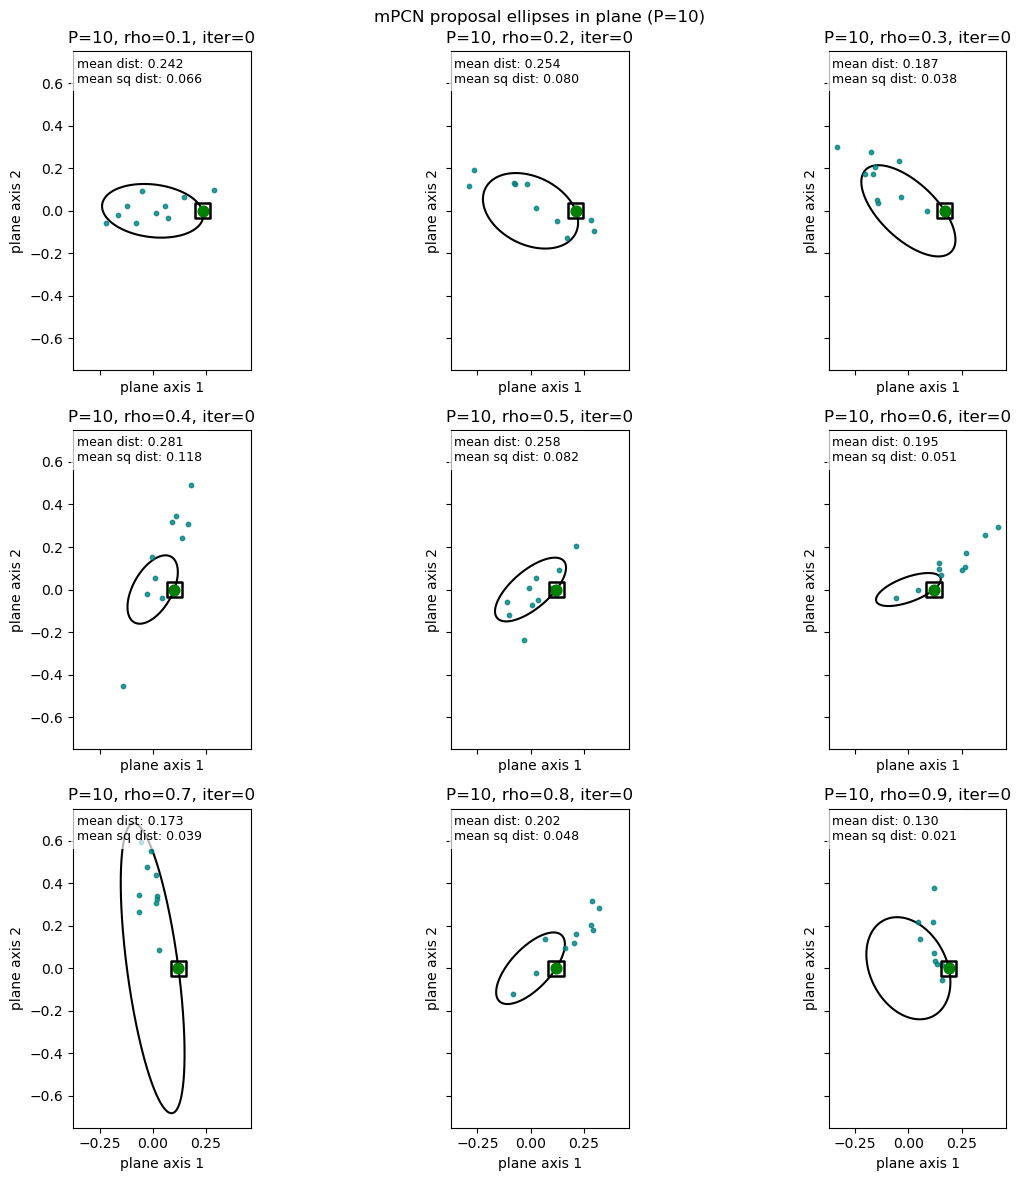

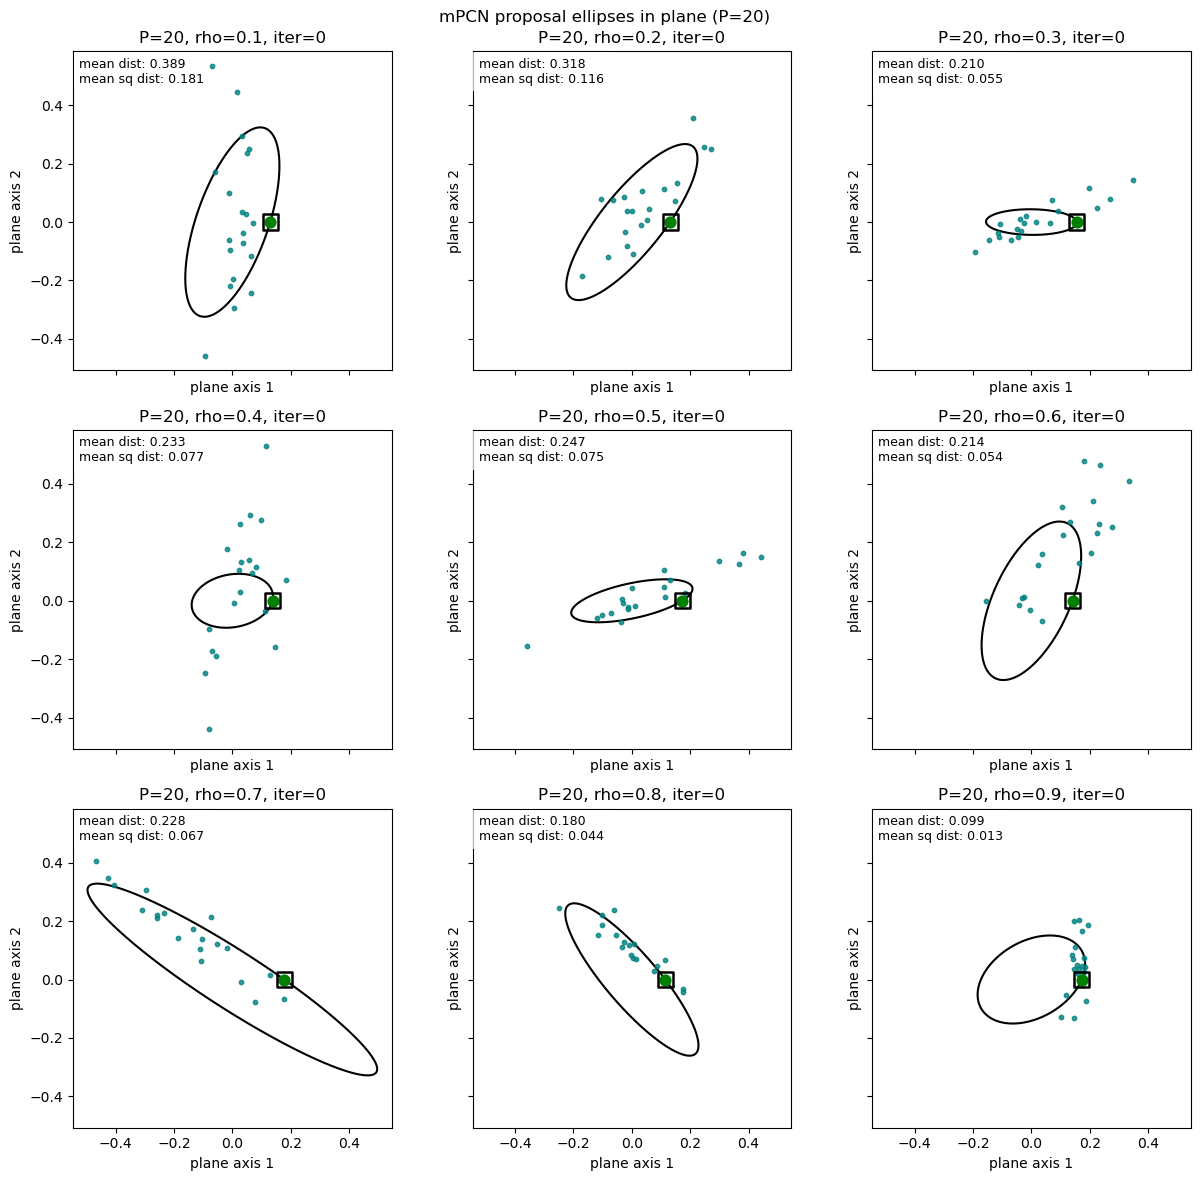

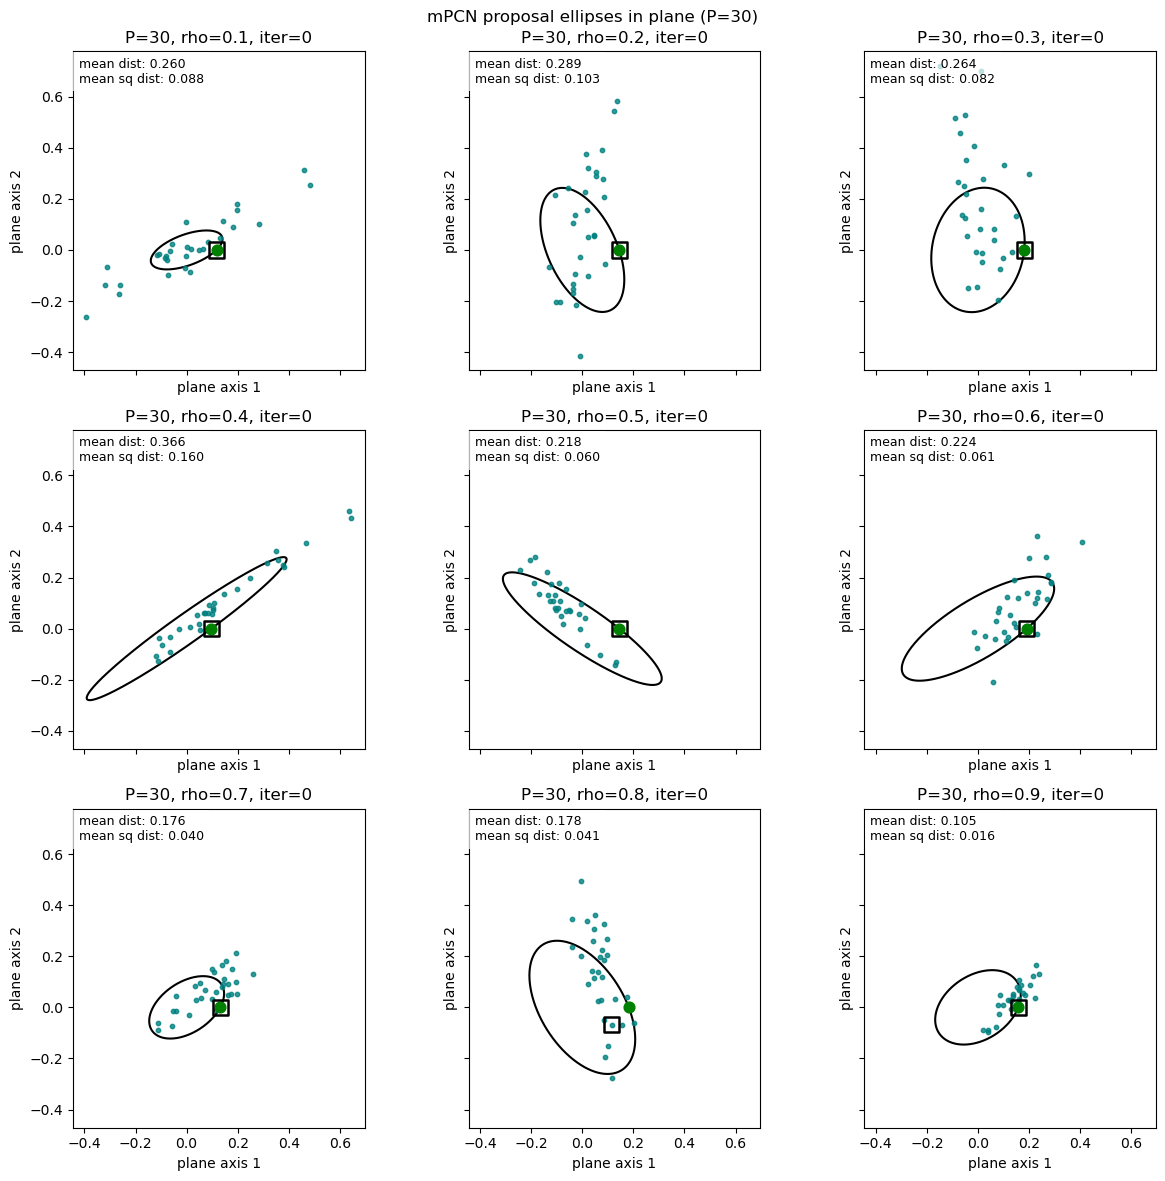

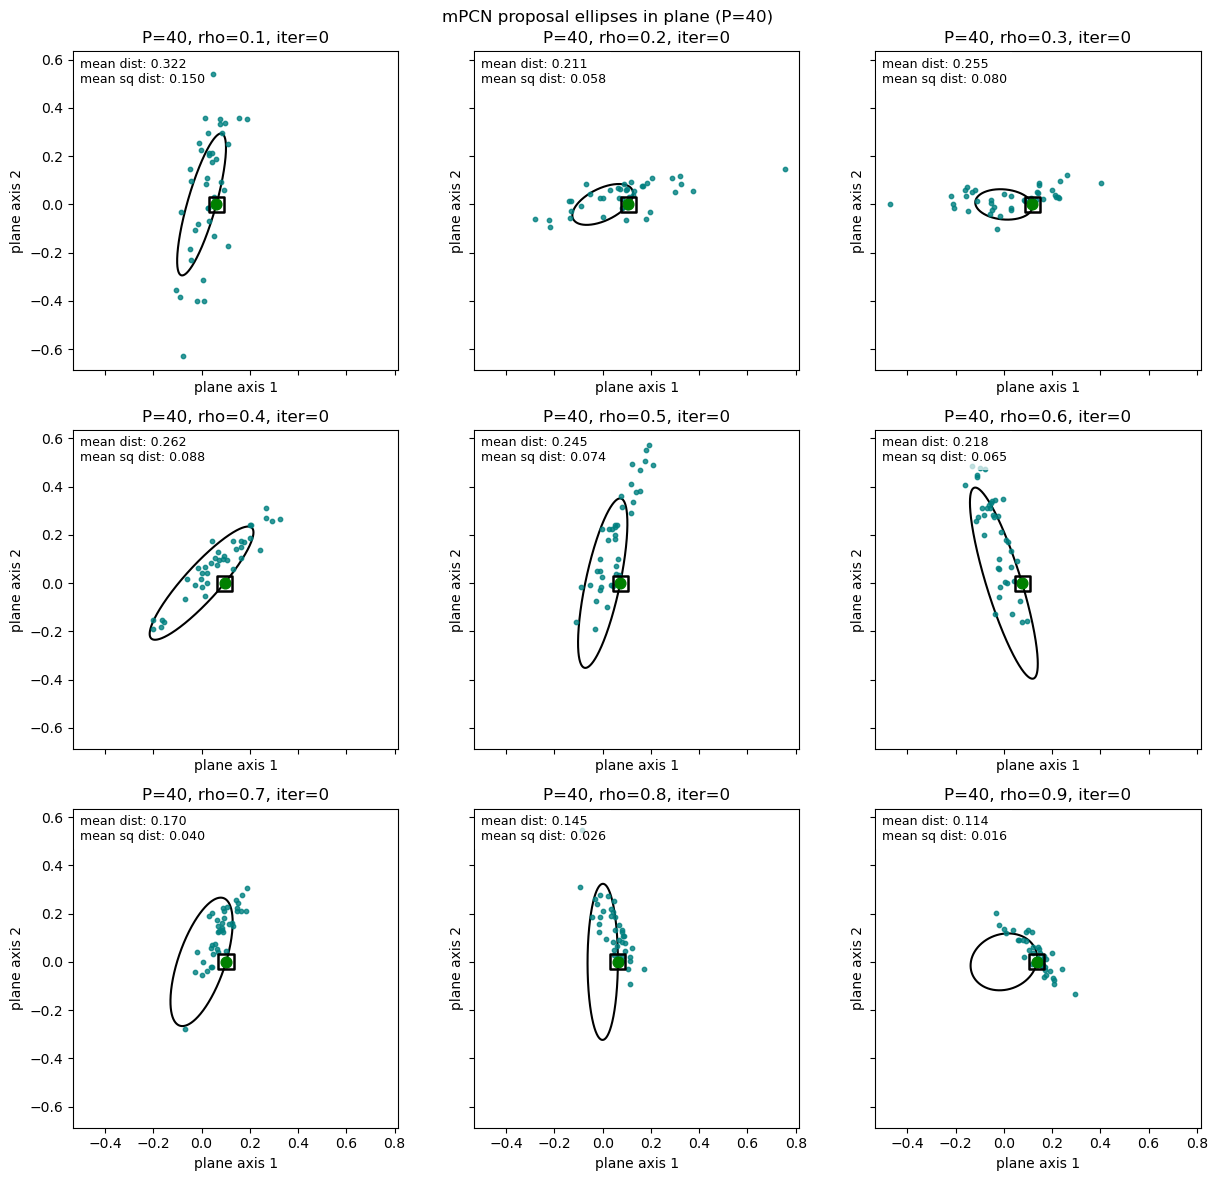

In [8]:
def _plane_basis(x, nu_c, mu):
    u1 = x - mu
    norm1 = np.linalg.norm(u1)
    if norm1 > 0:
        u1 = u1 / norm1
    else:
        u1 = np.zeros_like(x)
        u1[0] = 1.0
    u2 = nu_c - np.dot(nu_c, u1) * u1
    norm2 = np.linalg.norm(u2)
    if norm2 <= 1e-12:
        for k in range(u1.size):
            e = np.zeros_like(u1)
            e[k] = 1.0
            v = e - np.dot(e, u1) * u1
            if np.linalg.norm(v) > 1e-12:
                u2 = v
                break
        norm2 = np.linalg.norm(u2)
    u2 = u2 / norm2 if norm2 > 0 else np.zeros_like(u1)
    return u1, u2


def _project_to_plane(points, mu, u1, u2):
    dif = points - mu[None, :]
    return np.stack([dif @ u1, dif @ u2], axis=-1)


def plot_mpcn_snapshot(ax, snapshot, P, rho, iter_idx):
    if snapshot is None:
        ax.axis('off')
        ax.set_title(f'P={P}, rho={rho:.1f} (no snapshot)')
        return
    mu = np.zeros(problem.dim)
    x = snapshot['x']
    nu_c = snapshot['nu_c']
    props = snapshot['props']
    candidates = snapshot['candidates']
    logy = snapshot['logy']
    accepted_idx = snapshot['accepted_idx']
    mean_dist = snapshot['mean_dist']
    mean_sq_dist = snapshot['mean_sq_dist']

    u1, u2 = _plane_basis(x, nu_c, mu)
    theta = np.linspace(0.0, 2.0 * np.pi, 800)
    ellipse = mu + np.cos(theta)[:, None] * (x - mu) + np.sin(theta)[:, None] * nu_c
    ellipse_2d = _project_to_plane(ellipse, mu, u1, u2)

    prop_log_like = np.array([problem.log_likelihood(p) for p in props])
    above = prop_log_like >= logy
    props_2d = _project_to_plane(props, mu, u1, u2)
    candidates_2d = _project_to_plane(candidates, mu, u1, u2)
    x_2d = _project_to_plane(x[None, :], mu, u1, u2)[0]
    accepted_point = candidates_2d[accepted_idx]

    ax.plot(ellipse_2d[:, 0], ellipse_2d[:, 1], color='black', linewidth=1.5, zorder=2)
    ax.scatter(props_2d[~above, 0], props_2d[~above, 1], color='teal', s=10, alpha=0.8, label='props < logy', zorder=2)
    ax.scatter(props_2d[above, 0], props_2d[above, 1], color='teal', s=10, alpha=0.8, label='props >= logy', zorder=2)
    ax.scatter([x_2d[0]], [x_2d[1]], color='green', s=60, marker='o', label='current', zorder=3)
    ax.scatter([accepted_point[0]], [accepted_point[1]], facecolors='none', edgecolors='black',
               s=120, marker='s', linewidths=1.8, label='accepted', zorder=4)
    ax.text(
        0.02,
        0.98,
        f'mean dist: {mean_dist:.3f}\nmean sq dist: {mean_sq_dist:.3f}',
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
    )
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('plane axis 1')
    ax.set_ylabel('plane axis 2')
    ax.grid(False)
    ax.set_title(f'P={P}, rho={rho:.1f}, iter={iter_idx}')


n_rho = len(rho_list)
ncols = 3
nrows = int(np.ceil(n_rho / ncols))

for P in P_list:
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)
    for ax, rho in zip(axes, rho_list):
        snapshot = results['mpcn'][P][rho]['snapshot']
        plot_mpcn_snapshot(ax, snapshot, P, rho, plot_iter)
    for ax in axes[len(rho_list):]:
        ax.axis('off')
    fig.suptitle(f'mPCN proposal ellipses in plane (P={P})')
    fig.tight_layout()
    plt.show()

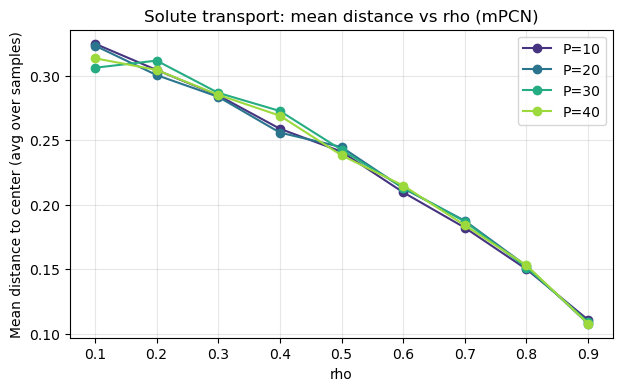

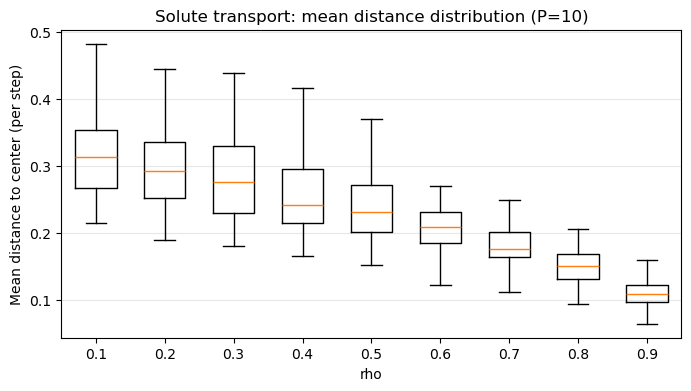

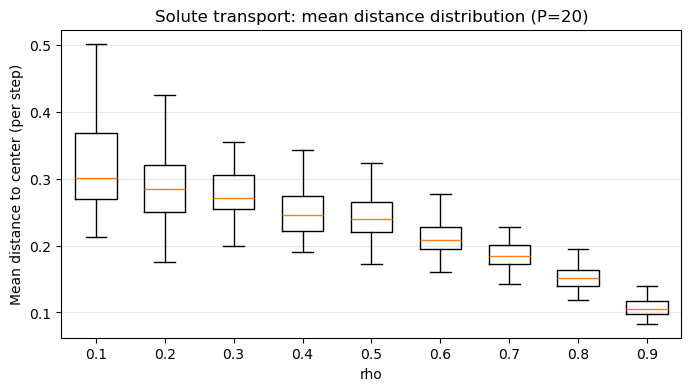

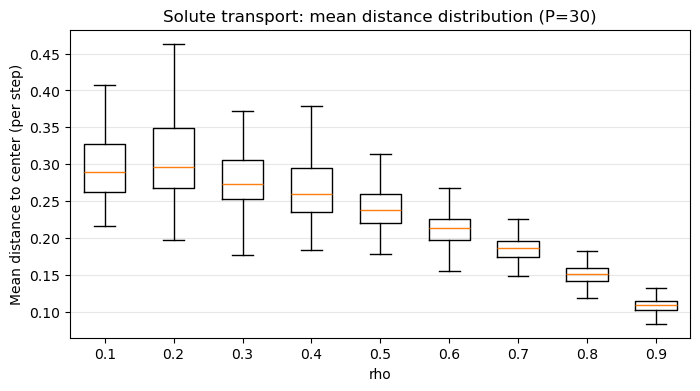

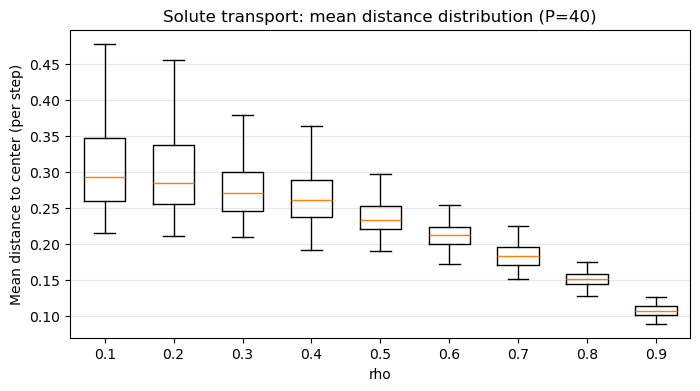

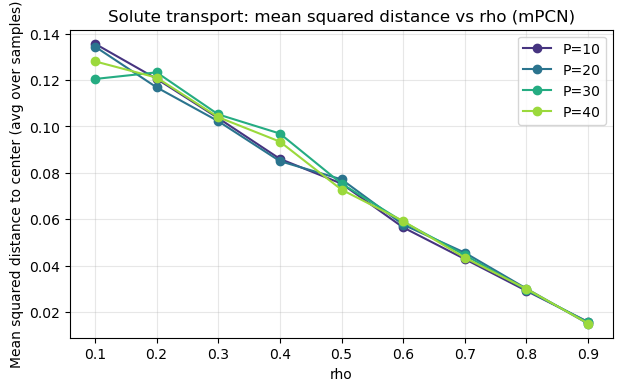

In [14]:
# Distance summaries vs rho (one curve per P)
P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}

fig, ax = plt.subplots(figsize=(7, 4))
for P in P_list:
    dist_vals = [np.mean(results['mpcn'][P][rho]['mean_dist_samples']) for rho in rho_list]
    ax.plot(rho_list, dist_vals, marker='o', color=color_by_P[P], label=f'P={P}')
ax.set_xlabel('rho')
ax.set_ylabel('Mean distance to center (avg over samples)')
ax.set_title('Solute transport: mean distance vs rho (mPCN)')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()

for P in P_list:
    fig, ax = plt.subplots(figsize=(8, 4))
    dist_samples = [results['mpcn'][P][rho]['mean_dist_samples'] for rho in rho_list]
    ax.boxplot(dist_samples, widths=0.6, showfliers=False)
    ax.set_xticks(np.arange(1, len(rho_list) + 1))
    ax.set_xticklabels([f'{rho:.1f}' for rho in rho_list])
    ax.set_xlabel('rho')
    ax.set_ylabel('Mean distance to center (per step)')
    ax.set_title(f'Solute transport: mean distance distribution (P={P})')
    ax.grid(alpha=0.3, axis='y')
    plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
for P in P_list:
    dist_vals = [np.mean(results['mpcn'][P][rho]['mean_sq_dist_samples']) for rho in rho_list]
    ax.plot(rho_list, dist_vals, marker='o', color=color_by_P[P], label=f'P={P}')
ax.set_xlabel('rho')
ax.set_ylabel('Mean squared distance to center (avg over samples)')
ax.set_title('Solute transport: mean squared distance vs rho (mPCN)')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()

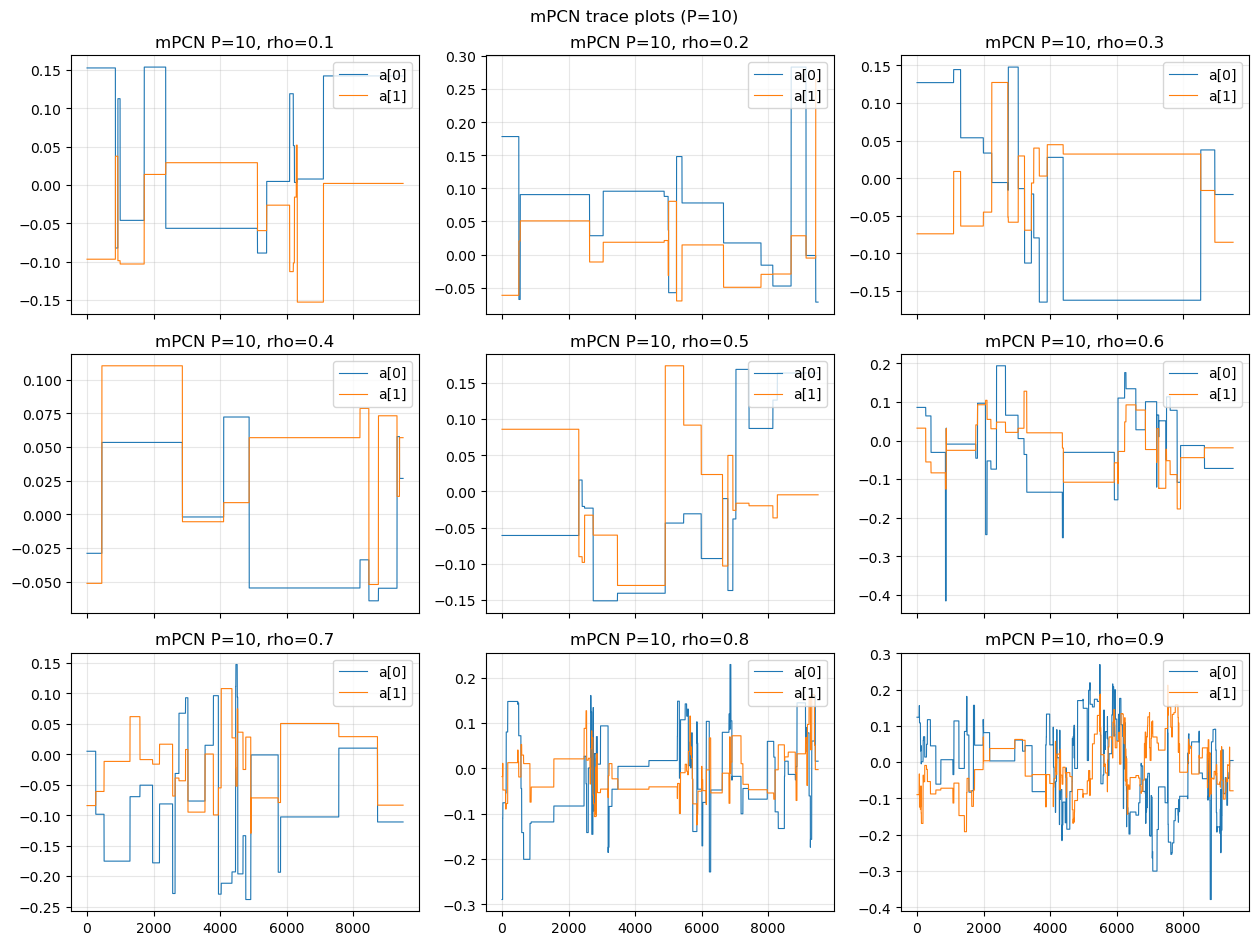

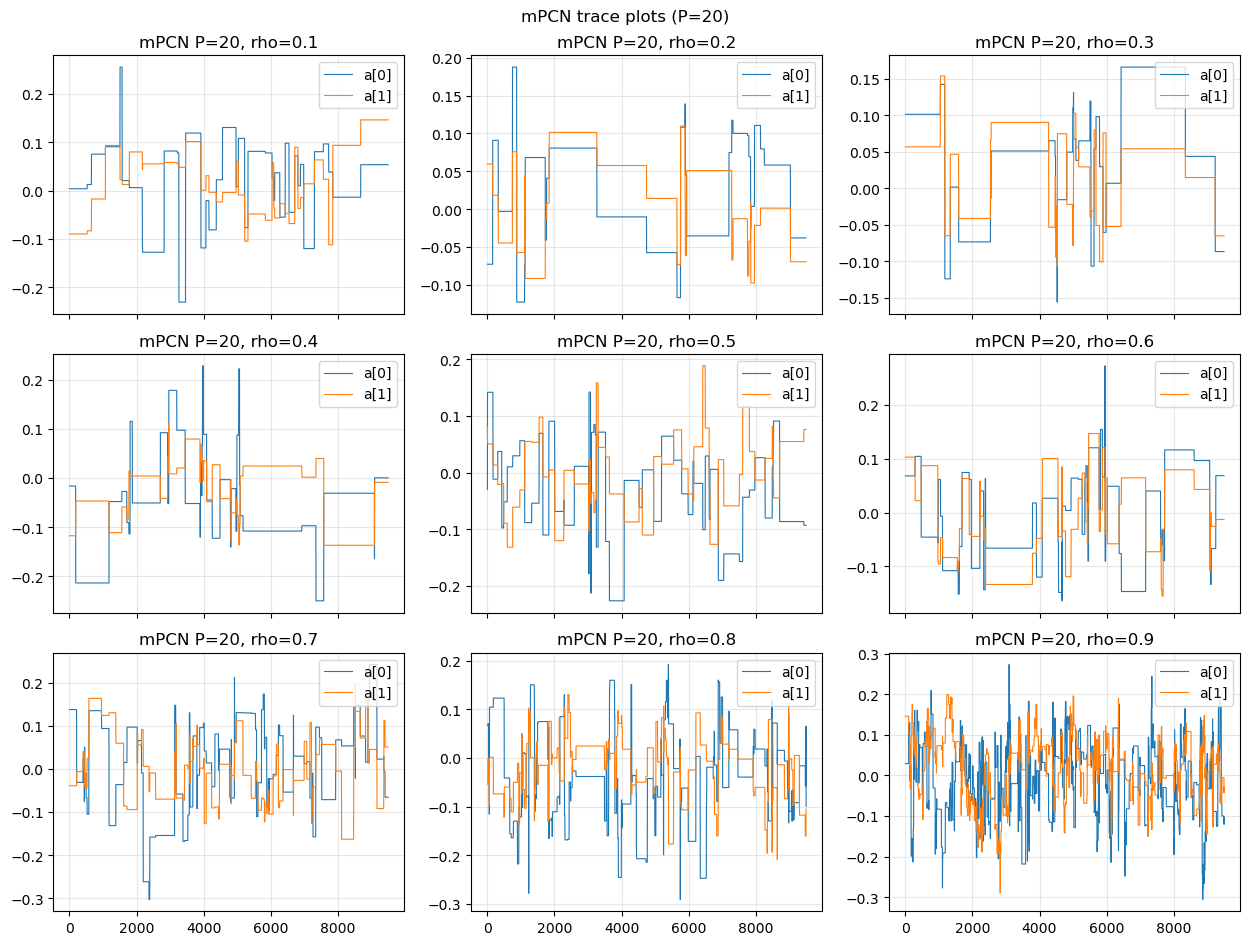

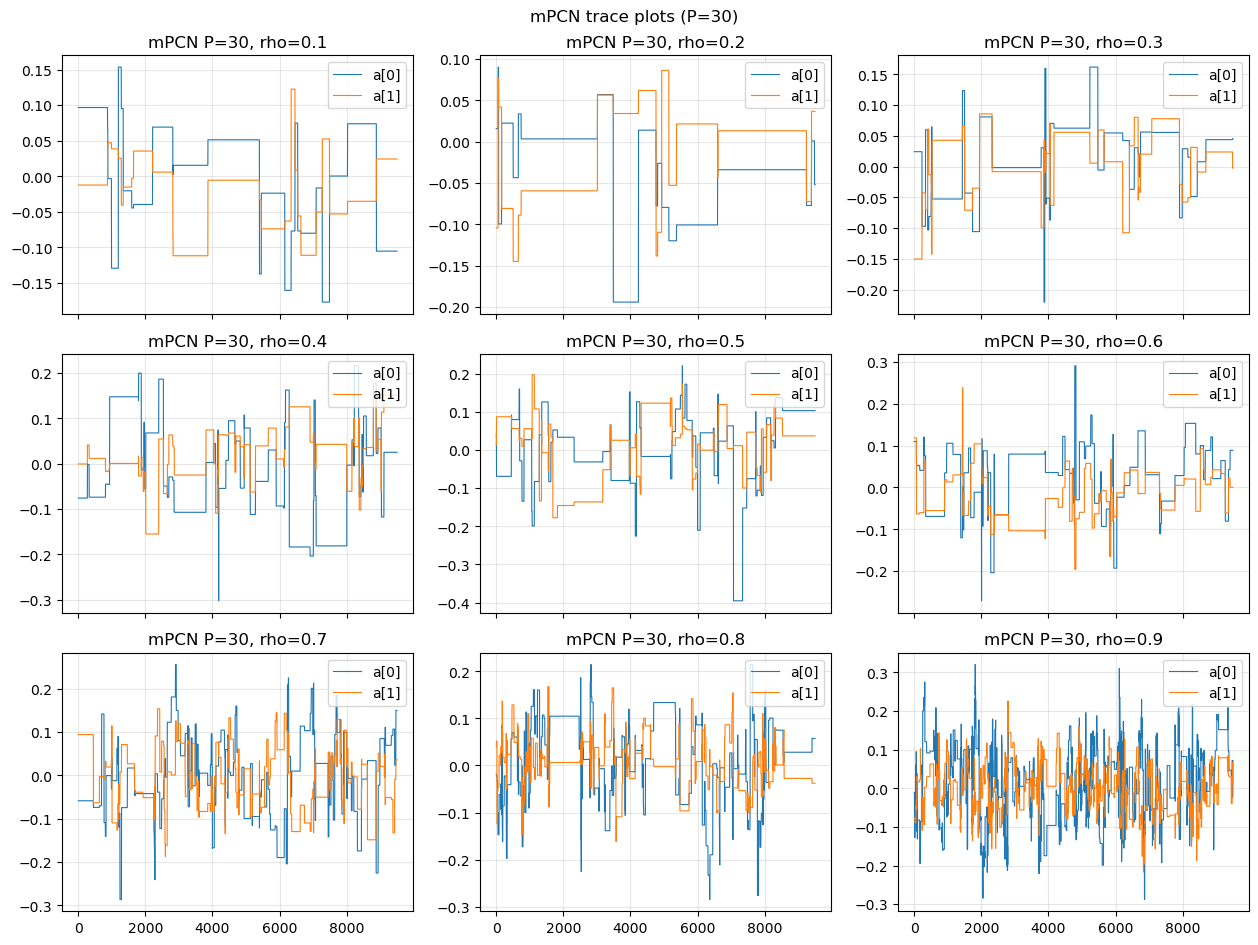

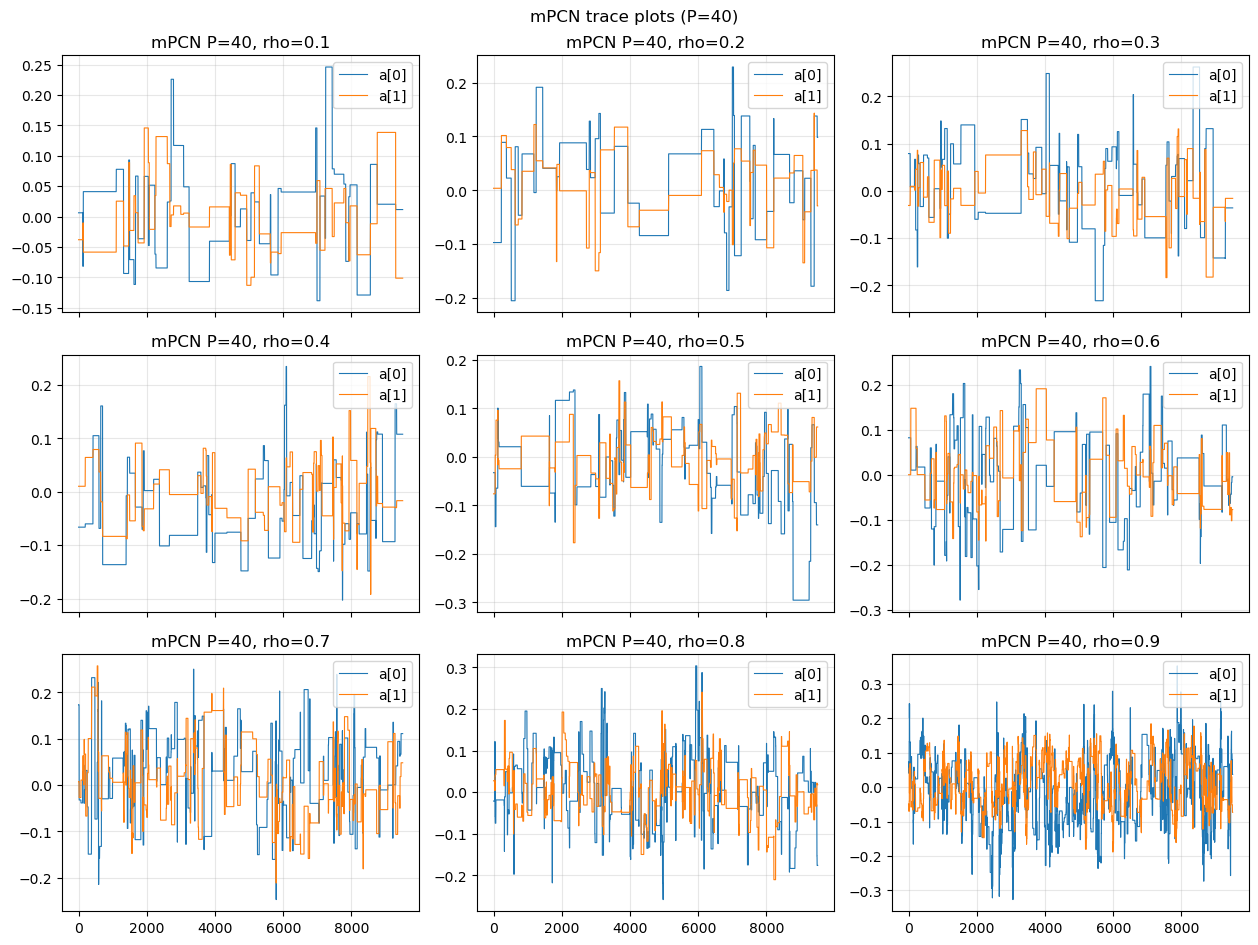

In [10]:
# Trace plots: one figure per P, subplots by rho
param_indices = [0, 1]
param_indices = [idx for idx in param_indices if idx < problem.dim]
n_rho = len(rho_list)
ncols = 3
nrows = int(np.ceil(n_rho / ncols))

for P in P_list:
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), sharex=True)
    axes = np.array(axes).reshape(-1)
    for ax, rho in zip(axes, rho_list):
        chain = results['mpcn'][P][rho]['chain'][burn_in:]
        for idx in param_indices:
            ax.plot(chain[:, idx], linewidth=0.8, label=f'a[{idx}]')
        ax.set_title(f'mPCN P={P}, rho={rho:.1f}')
        ax.grid(alpha=0.3)
        ax.legend(loc='upper right')
    for ax in axes[len(rho_list):]:
        ax.axis('off')
    fig.suptitle(f'mPCN trace plots (P={P})')
    fig.tight_layout()
    plt.show()

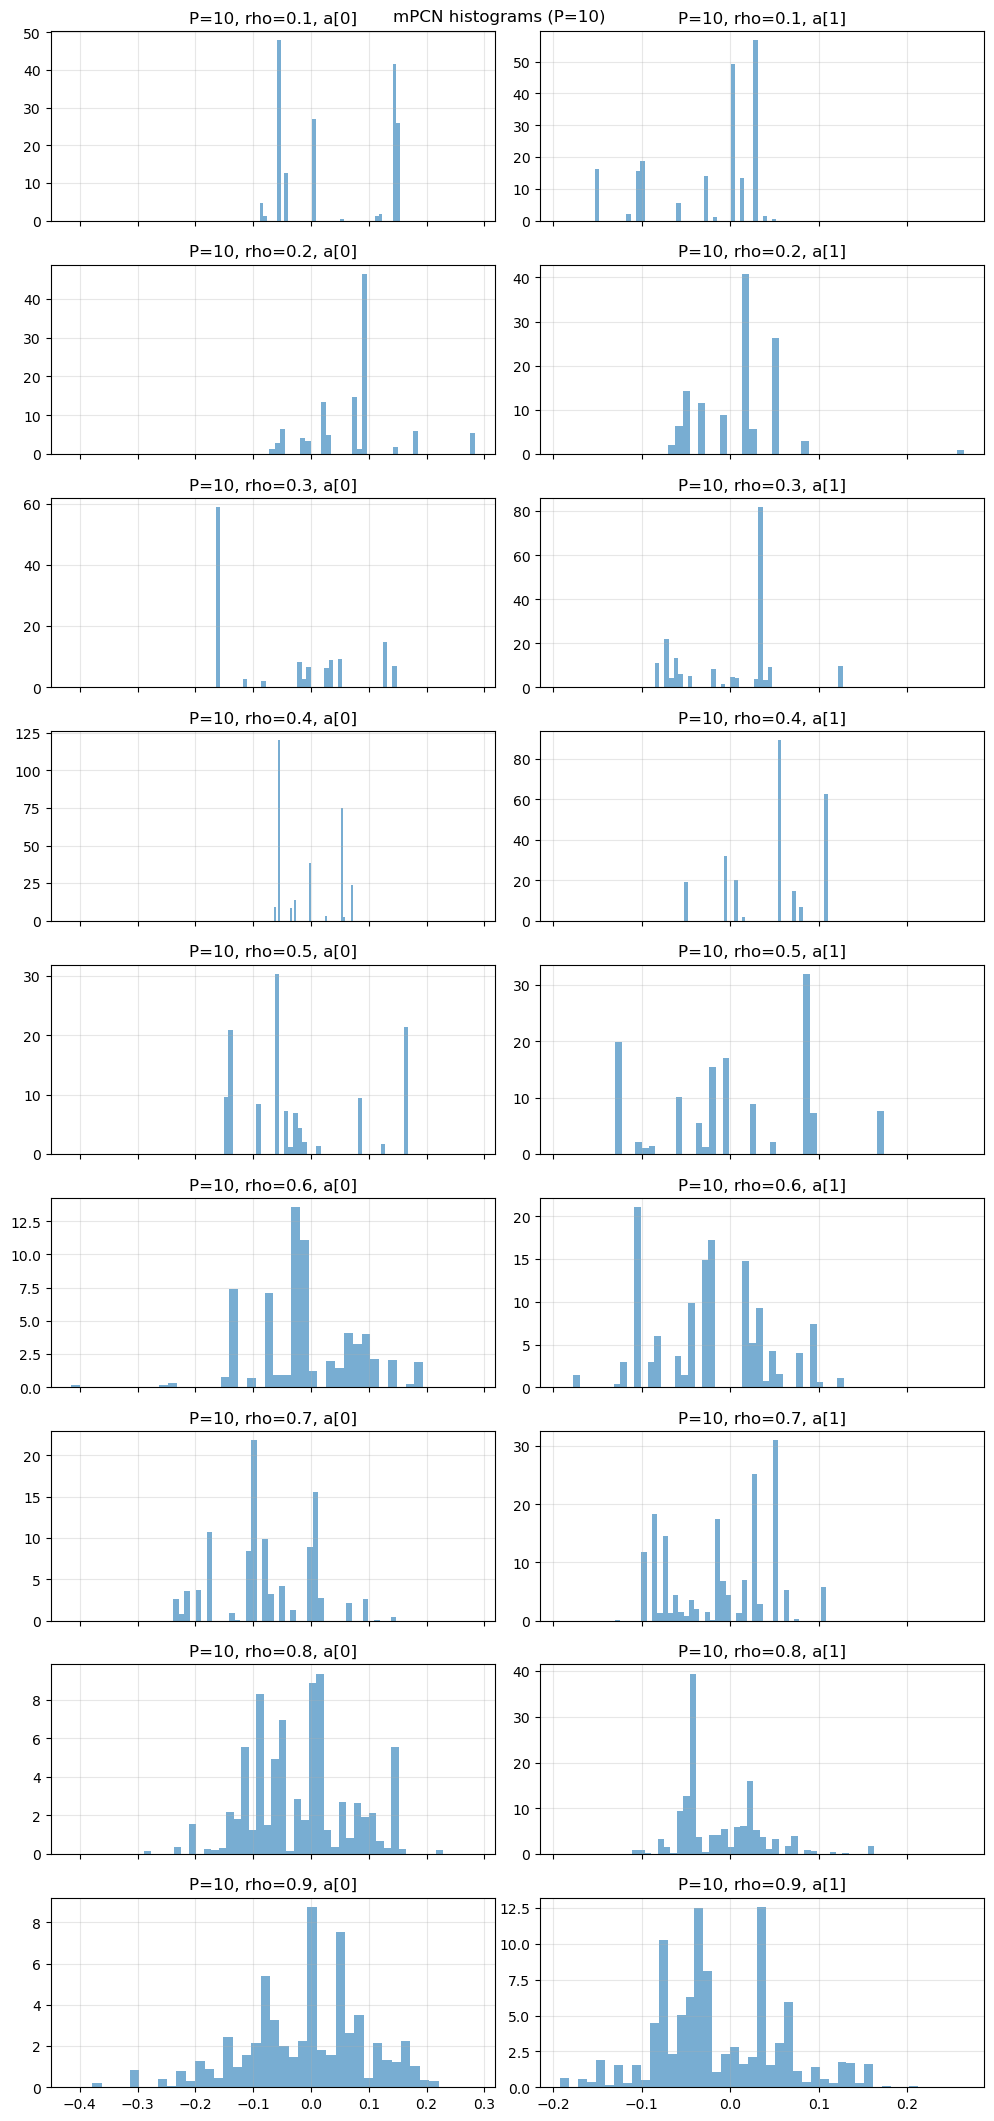

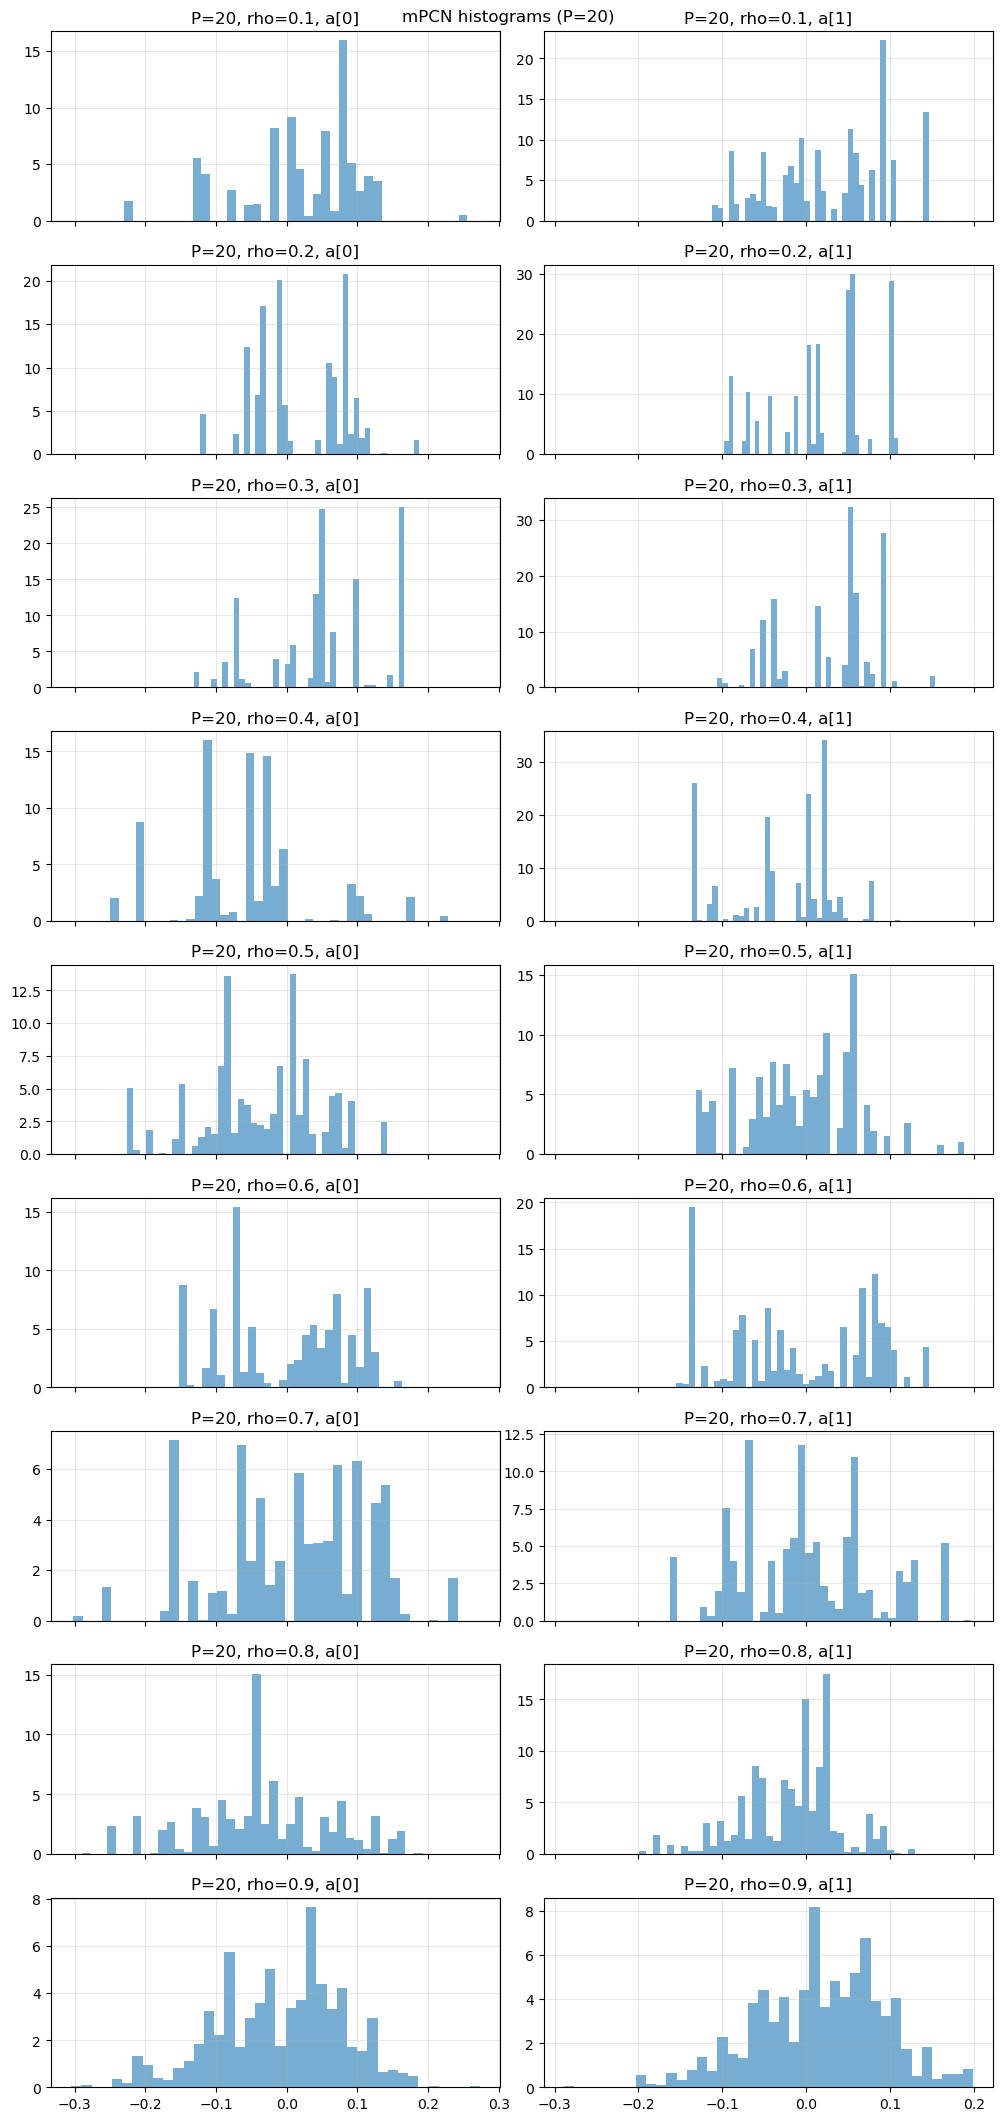

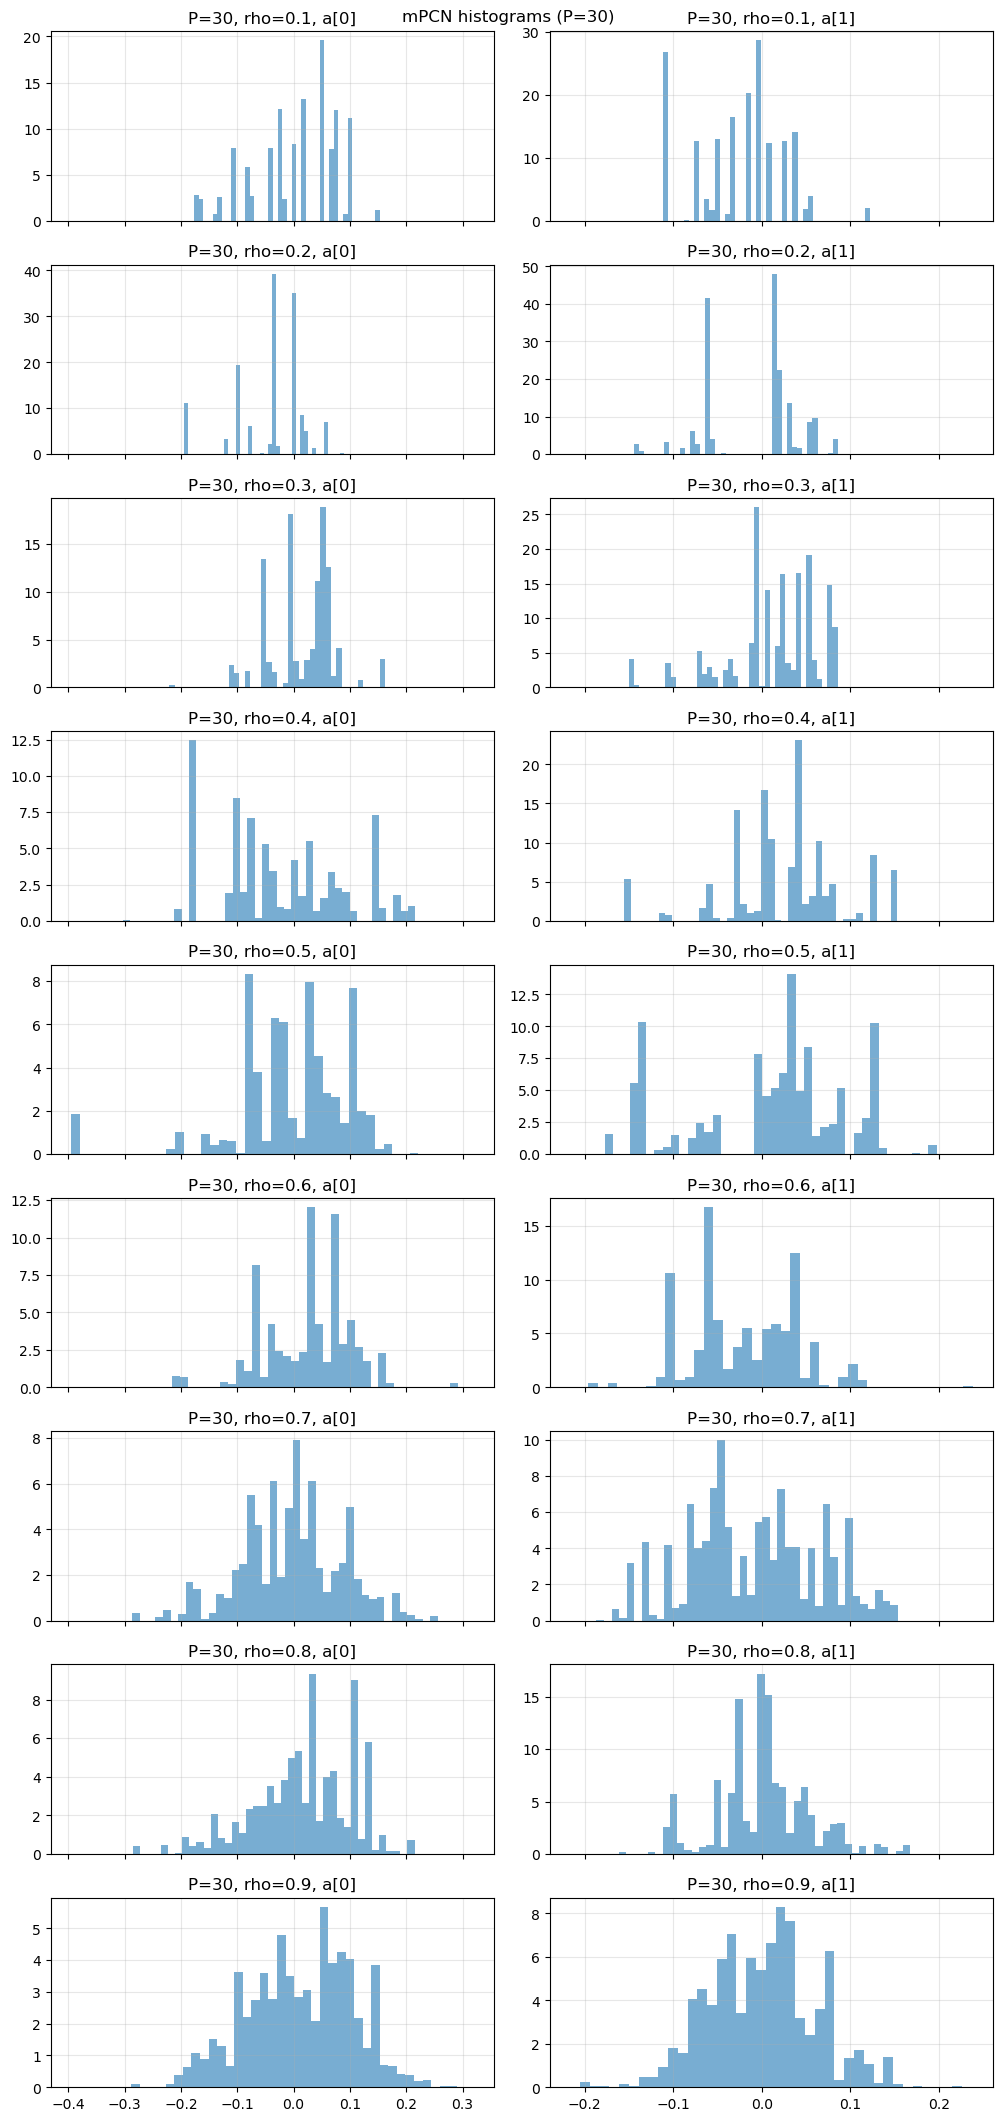

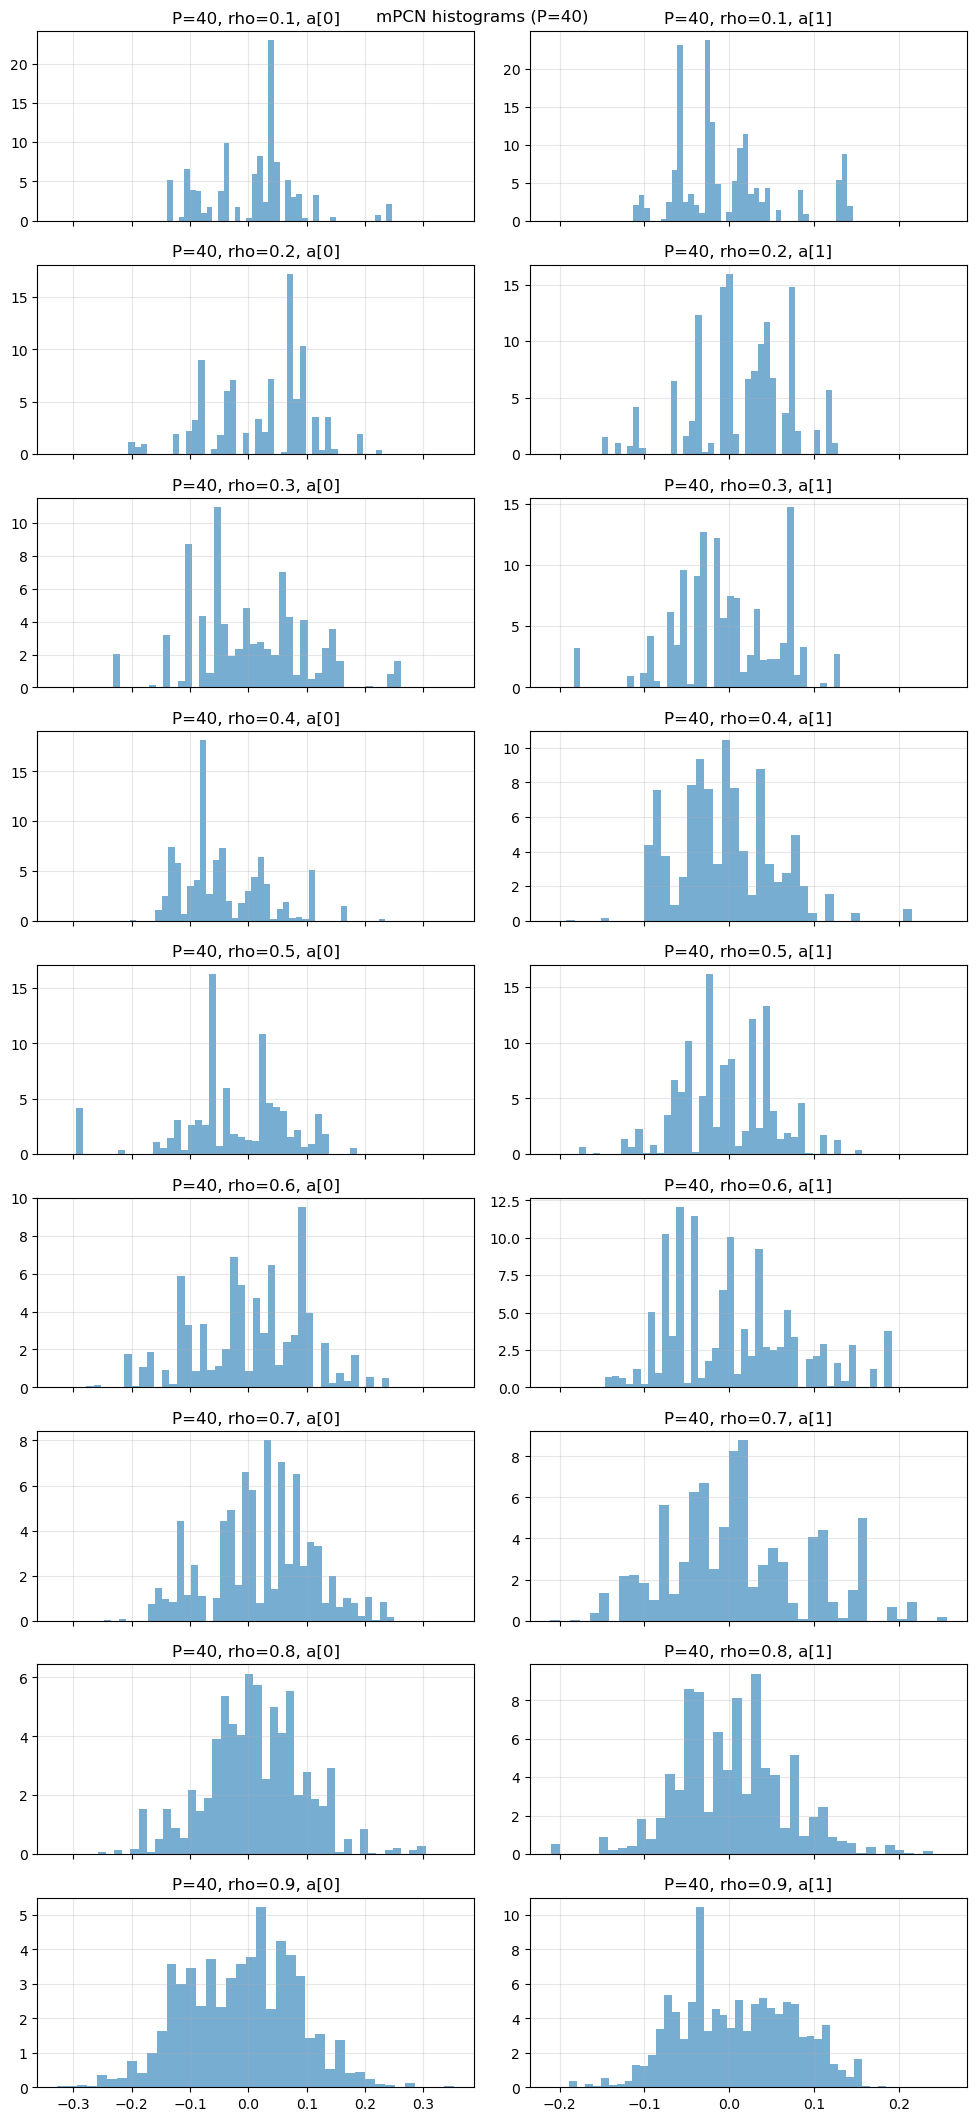

In [11]:
# Histograms: one figure per P, each rho has a panel per parameter
bins = 40
param_indices = [0, 1]
param_indices = [idx for idx in param_indices if idx < problem.dim]

for P in P_list:
    fig, axes = plt.subplots(len(rho_list), len(param_indices), figsize=(5 * len(param_indices), 2.4 * len(rho_list)), sharex='col')
    if len(param_indices) == 1:
        axes = axes[:, None]
    for row_idx, rho in enumerate(rho_list):
        chain = results['mpcn'][P][rho]['chain'][burn_in:]
        for col_idx, p_idx in enumerate(param_indices):
            ax = axes[row_idx, col_idx]
            ax.hist(chain[:, p_idx], bins=bins, density=True, alpha=0.6)
            ax.set_title(f'P={P}, rho={rho:.1f}, a[{p_idx}]')
            ax.grid(alpha=0.3)
    fig.suptitle(f'mPCN histograms (P={P})')
    fig.tight_layout()
    plt.show()

In [ ]:
# Pairplots for a selected P and rho
from multiproposal.plotting.diagnostics import make_hist_grid_comps

P_pair = P_list[0]
rho_pair = rho_list[0]

comp_list = [0, 1]
comp_list = [idx for idx in comp_list if idx < problem.dim]
if len(comp_list) < 2:
    raise ValueError('Need at least two parameters for pairplots.')

post_chain_mpcn = results['mpcn'][P_pair][rho_pair]['chain'][burn_in:]
post_chain_mess_uniform = results['mess_uniform'][P_pair]['chain'][burn_in:]
post_chain_mess_euclid = results['mess_euclid_sq'][P_pair]['chain'][burn_in:]

combined = np.vstack([post_chain_mpcn, post_chain_mess_uniform, post_chain_mess_euclid])
R = 1.1 * np.max(np.abs(combined))
dr = 0.1

prior_cov = np.diag(data['prior_diag'])
label_map = {comp_list[0]: f'a[{comp_list[0]}]', comp_list[1]: f'a[{comp_list[1]}]'}
true_values = data.get('a_true', None)

_ = make_hist_grid_comps(
    R=R,
    dr=dr,
    samples=post_chain_mpcn,
    comp_list=comp_list,
    save_path=None,
    C=prior_cov,
    beta=0.95,
    hide_plot=False,
    label_map=label_map,
    font_size=12,
    title=f'mPCN Pairplot (P={P_pair}, rho={rho_pair:.1f})',
    true_values=true_values,
 )

_ = make_hist_grid_comps(
    R=R,
    dr=dr,
    samples=post_chain_mess_uniform,
    comp_list=comp_list,
    save_path=None,
    C=prior_cov,
    beta=0.95,
    hide_plot=False,
    label_map=label_map,
    font_size=12,
    title=f'MESS uniform Pairplot (M={P_pair})',
    true_values=true_values,
 )

_ = make_hist_grid_comps(
    R=R,
    dr=dr,
    samples=post_chain_mess_euclid,
    comp_list=comp_list,
    save_path=None,
    C=prior_cov,
    beta=0.95,
    hide_plot=False,
    label_map=label_map,
    font_size=12,
    title=f'MESS euclid^2 Pairplot (M={P_pair})',
    true_values=true_values,
 )

NameError: name 'make_hist_grid_comps' is not defined

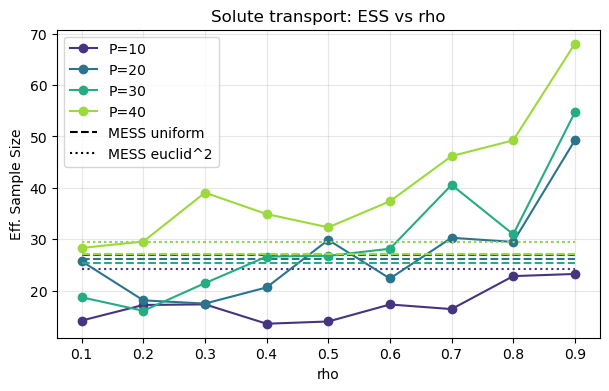

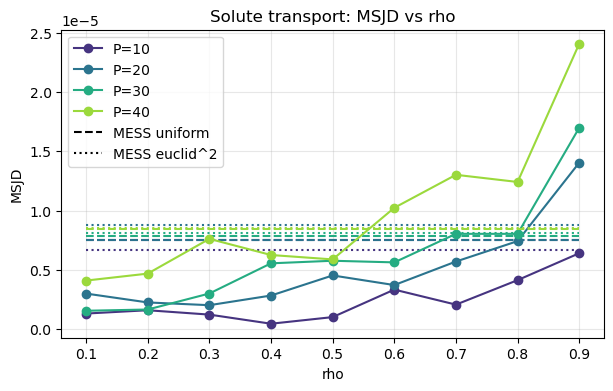

In [15]:
# ESS/MSJD vs rho curves (one line per P)
from matplotlib.lines import Line2D

P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}

fig, ax = plt.subplots(figsize=(7, 4))
for P in P_list:
    ess_vals = [results['mpcn'][P][rho]['metrics']['ess_mean'] for rho in rho_list]
    ax.plot(rho_list, ess_vals, marker='o', color=color_by_P[P], label=f'P={P}')
    mess_uniform = results['mess_uniform'][P]['metrics']['ess_mean']
    mess_euclid = results['mess_euclid_sq'][P]['metrics']['ess_mean']
    ax.plot(rho_list, [mess_uniform] * len(rho_list), linestyle='--', color=color_by_P[P])
    ax.plot(rho_list, [mess_euclid] * len(rho_list), linestyle=':', color=color_by_P[P])
ax.set_xlabel('rho')
ax.set_ylabel('Eff. Sample Size')
ax.set_title('Solute transport: ESS vs rho')
ax.grid(alpha=0.3)
color_handles = [
    Line2D([0], [0], color=color_by_P[P], marker='o', linestyle='-', label=f'P={P}')
    for P in P_sorted
    if P in color_by_P
 ]
style_handles = [
    Line2D([0], [0], color='black', linestyle='--', label='MESS uniform'),
    Line2D([0], [0], color='black', linestyle=':', label='MESS euclid^2'),
 ]
ax.legend(handles=color_handles + style_handles, loc='best')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
for P in P_list:
    msjd_vals = [results['mpcn'][P][rho]['metrics']['msjd_mean'] for rho in rho_list]
    ax.plot(rho_list, msjd_vals, marker='o', color=color_by_P[P], label=f'P={P}')
    mess_uniform = results['mess_uniform'][P]['metrics']['msjd_mean']
    mess_euclid = results['mess_euclid_sq'][P]['metrics']['msjd_mean']
    ax.plot(rho_list, [mess_uniform] * len(rho_list), linestyle='--', color=color_by_P[P])
    ax.plot(rho_list, [mess_euclid] * len(rho_list), linestyle=':', color=color_by_P[P])
ax.set_xlabel('rho')
ax.set_ylabel('MSJD')
ax.set_title('Solute transport: MSJD vs rho')
ax.grid(alpha=0.3)
color_handles = [
    Line2D([0], [0], color=color_by_P[P], marker='o', linestyle='-', label=f'P={P}')
    for P in P_sorted
    if P in color_by_P
 ]
style_handles = [
    Line2D([0], [0], color='black', linestyle='--', label='MESS uniform'),
    Line2D([0], [0], color='black', linestyle=':', label='MESS euclid^2'),
 ]
ax.legend(handles=color_handles + style_handles, loc='best')
plt.show()

In [16]:
# ESS/MSJD tables (rows=P, columns=rho + MESS)
ess_rows = []
msjd_rows = []
row_labels = []
col_labels = [f'rho={rho:.1f}' for rho in rho_list] + ['mess_uniform', 'mess_euclid_sq']

for P in P_list:
    ess_row = [results['mpcn'][P][rho]['metrics']['ess_mean'] for rho in rho_list]
    msjd_row = [results['mpcn'][P][rho]['metrics']['msjd_mean'] for rho in rho_list]
    ess_row.append(results['mess_uniform'][P]['metrics']['ess_mean'])
    msjd_row.append(results['mess_uniform'][P]['metrics']['msjd_mean'])
    ess_row.append(results['mess_euclid_sq'][P]['metrics']['ess_mean'])
    msjd_row.append(results['mess_euclid_sq'][P]['metrics']['msjd_mean'])
    ess_rows.append(ess_row)
    msjd_rows.append(msjd_row)
    row_labels.append(f'P={P}')

ess_table = pd.DataFrame(ess_rows, index=row_labels, columns=col_labels)
msjd_table = pd.DataFrame(msjd_rows, index=row_labels, columns=col_labels)

print('ESS table (mPCN across rho, MESS in last columns):')
display(ess_table)
print('MSJD table (mPCN across rho, MESS in last columns):')
display(msjd_table)

ESS table (mPCN across rho, MESS in last columns):


,rho=0.1,rho=0.2,rho=0.3,rho=0.4,rho=0.5,rho=0.6,rho=0.7,rho=0.8,rho=0.9,mess_uniform,mess_euclid_sq
P=10,14.175435,17.205834,17.323417,13.558316,13.993042,17.301738,16.405051,22.818682,23.238336,26.880042,24.129240
P=20,25.715570,18.105190,17.475173,20.622388,29.856290,22.356031,30.280125,29.463152,49.250804,26.240981,26.924256
P=30,18.696074,16.077050,21.453962,26.615781,26.770909,28.144343,40.572246,30.951874,54.671557,25.423115,29.510595
P=40,28.305491,29.545926,39.052800,34.894557,32.306763,37.381733,46.171827,49.231909,68.029029,27.094586,29.466513


MSJD table (mPCN across rho, MESS in last columns):


,rho=0.1,rho=0.2,rho=0.3,rho=0.4,rho=0.5,rho=0.6,rho=0.7,rho=0.8,rho=0.9,mess_uniform,mess_euclid_sq
P=10,0.000001,0.000002,0.000001,4.613338e-07,0.000001,0.000003,0.000002,0.000004,0.000006,0.000008,0.000007
P=20,0.000003,0.000002,0.000002,2.838911e-06,0.000005,0.000004,0.000006,0.000007,0.000014,0.000008,0.000009
P=30,0.000002,0.000002,0.000003,5.555669e-06,0.000006,0.000006,0.000008,0.000008,0.000017,0.000008,0.000008
P=40,0.000004,0.000005,0.000008,6.257463e-06,0.000006,0.000010,0.000013,0.000012,0.000024,0.000008,0.000009
